# Problem set 2: Descriptive economics

**Learning goals:**

- Using basic `pandas` DataFrame operations
- Clean and structure data
- Download real economic datasets using an API
- Merge and join data sets
- Compute summary statistics

**Table of contents**<a id='toc0_'></a>    
- 1. [Basic pandas](#toc1_)    
  - 1.1. [Dataframe](#toc1_1_)    
  - 1.2. [New variable](#toc1_2_)    
  - 1.3. [Indexing](#toc1_3_)    
  - 1.4. [Changing variables](#toc1_4_)    
  - 1.5. [Dropping observations and columns](#toc1_5_)    
  - 1.6. [Renaming](#toc1_6_)    
  - 1.7. [Income distribution](#toc1_7_)    
- 2. [National account identity](#toc2_)    
  - 2.1. [Download](#toc2_1_)    
  - 2.2. [Merge](#toc2_2_)    
  - 2.3. [Split-apply-combine-plot](#toc2_3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [122]:
import numpy as np
import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

from dstapi import DstApi

## 1. <a id='toc1_'></a>[Basic pandas](#toc0_)

### 1.1. <a id='toc1_1_'></a>[Dataframe](#toc0_)

Modify the code below such that *income* and *consumption* are variables in the *df* DataFrame.

In [123]:
np.random.seed(1999)
 
N = 100
mydata = {}
mydata['id'] = range(N)
income = np.exp(np.random.normal(size=N))
consumption = np.sqrt(income)

df = pd.DataFrame(mydata)
df.head()

,id
0,0
1,1
2,2
3,3
4,4


In [124]:
display(df)

,id
0,0
1,1
2,2
3,3
4,4
...,...
95,95
96,96
97,97
98,98


In [125]:
N = 100
mydata = {}
mydata['id'] = range(N)
mydata['income'] = np.exp(np.random.normal(size=N))
mydata['consumption'] = np.sqrt(mydata['income'])

df_true = pd.DataFrame(mydata)

In [126]:
display(df_true.head())

,id,income,consumption
0,0,0.599145,0.774044
1,1,0.469167,0.684957
2,2,1.435292,1.198037
3,3,2.504716,1.582629
4,4,0.156667,0.395811


### 1.2. <a id='toc1_2_'></a>[New variable](#toc0_)

Create a new variable *ratio* which is the ratio of consumption to income.

In [127]:
# write your code here
df_true['ratio'] = df_true['consumption']/df_true['income']
df_true.head()

,id,income,consumption,ratio
0,0,0.599145,0.774044,1.291916
1,1,0.469167,0.684957,1.459945
2,2,1.435292,1.198037,0.834699
3,3,2.504716,1.582629,0.631860
4,4,0.156667,0.395811,2.526456


### 1.3. <a id='toc1_3_'></a>[Indexing](#toc0_)

**Question a:** Select everybody: with an income above 1.

In [128]:
# write your code here
I = df_true['income'] > 1
df_true.loc[I, :].head()

,id,income,consumption,ratio
2,2,1.435292,1.198037,0.834699
3,3,2.504716,1.582629,0.631860
5,5,6.455119,2.540693,0.393593
7,7,3.680231,1.918393,0.521270
8,8,1.000415,1.000207,0.999793


**Question b:** Select everybody with an income *above* 1 and a ratio *above* 0.7.

In [129]:
# write your code here
I = (df_true['income'] > 1) & (df_true['ratio'] > 0.7)
df_true.loc[I].head()

,id,income,consumption,ratio
2,2,1.435292,1.198037,0.834699
8,8,1.000415,1.000207,0.999793
10,10,1.993967,1.412079,0.708176
12,12,1.006071,1.003031,0.996978
13,13,1.590549,1.261170,0.792915


### 1.4. <a id='toc1_4_'></a>[Changing variables](#toc0_)

**Question a:** Set consumption equal to 0.5 if income is less than 0.5.

In [130]:
# write your code here
I = (df_true['income'] < 0.5)
df_true.loc[I, ['consumption']] = 0.5
df_true['consumption'].mean()
# df['consumption'].mean() # <- compare with answer

1.0981102517957049

**Question b:** Set consumption equal to income if income is less than 0.5.

In [131]:
# write your code here
I = (df_true['income'] < 0.5)
df_true.loc[I, ['consumption']] = df_true.loc[I, ['income']].values
df_true['consumption'].mean()
# df['consumption'].mean() # <- compare with answer

1.0525706254602272

### 1.5. <a id='toc1_5_'></a>[Dropping observations and columns](#toc0_)

Drop the *ratio* variable and all rows with an income above 1.5. After this, also drop the first 5 rows.

In [132]:
print(f'before: {df.shape[0]} observations, {df.shape[1]} variables')
# write your code here
print(f'after: {df.shape[0]} observations, {df.shape[1]} variables')
df_alt = df_true.copy()

print(f'before: {df_true.shape[0]} observations, {df_true.shape[1]} variables')
df_true = df_true.drop('ratio',axis=1)
I = df_true['income'] > 1.5
df_true = df_true.drop(df_true[I].index)
df_true = df_true.drop(df_true.loc[:5].index)
print(f'after: {df_true.shape[0]} observations, {df_true.shape[1]} variables')

# alternative: keep where I is false
del df_alt['ratio']
I = df_alt['income'] > 1.5
df_alt = df_alt[~I]
df_alt = df_alt.iloc[4:,:]
print(f'after (alt): {df_alt.shape[0]} observations, {df_alt.shape[1]} variables')

before: 100 observations, 1 variables
after: 100 observations, 1 variables
before: 100 observations, 4 variables
after: 66 observations, 3 variables
after (alt): 66 observations, 3 variables


### 1.6. <a id='toc1_6_'></a>[Renaming](#toc0_)

Rename *consumption* to *cons* and *income* to *inc*.

In [133]:
# write your code
df_true = df_true.rename(columns={'income':'inc','consumption':'con'})
df_true.head()

,id,inc,con
6,6,0.420303,0.420303
8,8,1.000415,1.000207
9,9,0.878953,0.937525
11,11,0.794194,0.891176
12,12,1.006071,1.003031


In [134]:
N = 100
mydata = {}
mydata['id'] = range(N)
mydata['income'] = np.exp(np.random.normal(size=N))
mydata['consumption'] = np.sqrt(mydata['income'])

df_true = pd.DataFrame(mydata)

df_true = df_true.rename(columns={'income':'inc','consumption':'con'})
df_true.head()

,id,inc,con
0,0,8.396814,2.897726
1,1,1.654535,1.286287
2,2,0.235876,0.485671
3,3,0.365096,0.604231
4,4,0.960915,0.980263


### 1.7. <a id='toc1_7_'></a>[Income distribution](#toc0_)

Compute the share of income for each decile of the income distribution using the code below as a starting point.

In [135]:
# deciles = df.quantile(?)
# df[?] = pd.cut(?,labels=?)
# income_shares df.groupby(?)[?].? / ?
# display(income_shares)
deciles = df_true.quantile([0.1 * i for i in range(1, 10)])
df_true['decile'] = pd.cut(df_true['inc'], bins=[-np.inf] + list(deciles['inc']) + [np.inf], labels=range(1, 11))
income_share = df_true.groupby('decile')['inc'].sum() / df_true['inc'].sum()
display(income_share)

/var/folders/7z/npwd4mkj50g10rrf3zlkgr4m0000gn/T/ipykernel_36473/2925055179.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_share = df_true.groupby('decile')['inc'].sum() / df_true['inc'].sum()


decile
1     0.011274
2     0.019369
3     0.026195
4     0.033706
5     0.045973
6     0.060323
7     0.079245
8     0.109833
9     0.173969
10    0.440115
Name: inc, dtype: float64

## 2. <a id='toc2_'></a>[National account identity](#toc0_)

### 2.1. <a id='toc2_1_'></a>[Download](#toc0_)

Consider the following dictionary definitions:

In [136]:
columns_dict = {}
columns_dict['TRANSAKT'] = 'variable'
columns_dict['PRISENHED'] = 'unit'
columns_dict['TID'] = 'year'
columns_dict['INDHOLD'] = 'value'

var_dict = {} # var is for variable
var_dict['P.1 Output'] = 'Y'
var_dict['P.3 Final consumption expenditure'] = 'C'
var_dict['P.3 Government consumption expenditure'] = 'G'
var_dict['P.5 Gross capital formation'] = 'I'
var_dict['P.6 Export of goods and services'] = 'X'
var_dict['P.7 Import of goods and services'] = 'M'

unit_dict = {}
unit_dict['2020-prices, chained values'] = 'real'
unit_dict['Current prices'] = 'nominal'

**Step 1:** Download all of table `nah1`.

In [137]:
# hint, nah1_api = DstApi('?') 
# hint, params = nah1_api._define_base_params(language='en')
# display(params)
# nah1 = nah1_api.get_data(?)
# a. load
nah1_api = DstApi('NAH1') 
params = nah1_api._define_base_params(language='en')
nah1_true = nah1_api.get_data(params=params)



**Step 2:** Rename the columns using `columns_dict` and replace data using `var_dict` and `unit_dict`.

In [138]:
# hint, nah1_true = nah1_true.rename(?)

# for key,value in var_dict.items():
#   nah1.variable.replace(?)

#for key,value in unit_dict.items():
#   nah1.unit.replace(?)
# b. rename and replace
nah1_true = nah1_true.rename(columns=columns_dict)
display(nah1_true.head())



,variable,unit,year,value
0,D.21 Taxes on products,"2020-prices, chained values",1992,190426
1,D.21 Taxes on products,Current prices,1992,134646
2,D.21-D.31 Taxes less subsidies on products,"2020-prices, chained values",1992,178691
3,D.21-D.31 Taxes less subsidies on products,Current prices,1992,119558
4,D.31 Subsidies on products,"2020-prices, chained values",1992,12676


**Step 3:** Only keep rows where the variable is in `[Y, C, G, I, X, M]`. Afterwards convert the `value` column to a float.

In [139]:
# write you code here
# nah1.value = nah1.value.astype('float')
# # c. replace data
for key,value in var_dict.items():
   nah1_true.variable = nah1_true.variable.replace(key,value)

for key,value in unit_dict.items():
   nah1_true.unit = nah1_true.unit.replace(key,value)
# nah1.groupby(['variable','unit']).describe()
# d. keep if in var_dict
I = False
for key,value in var_dict.items():
    I = I | (nah1_true.variable == value)
nah1_true = nah1_true[I]
   
# e. convert values to numeric
nah1_true.value = nah1_true.value.astype('float')


**Step 4:** Discuss what the following summary statistics show.

In [140]:


# d. summary statistics
nah1_true.groupby(['variable','unit']).describe()



year                                                     \
                 count    mean        std     min     25%     50%     75%   
variable unit                                                               
C        nominal  59.0  1995.0  17.175564  1966.0  1980.5  1995.0  2009.5   
         real     59.0  1995.0  17.175564  1966.0  1980.5  1995.0  2009.5   
G        nominal  59.0  1995.0  17.175564  1966.0  1980.5  1995.0  2009.5   
         real     59.0  1995.0  17.175564  1966.0  1980.5  1995.0  2009.5   
I        nominal  59.0  1995.0  17.175564  1966.0  1980.5  1995.0  2009.5   
         real     59.0  1995.0  17.175564  1966.0  1980.5  1995.0  2009.5   
M        nominal  59.0  1995.0  17.175564  1966.0  1980.5  1995.0  2009.5   
         real     59.0  1995.0  17.175564  1966.0  1980.5  1995.0  2009.5   
X        nominal  59.0  1995.0  17.175564  1966.0  1980.5  1995.0  2009.5   
         real     59.0  1995.0  17.175564  1966.0  1980.5  1995.0  2009.5   
Y        nominal  59.0  1995.0  17.175564  1966.0  1980.5  1995.0  2009.5   
         real     59.0  1995.0  17.175564  1966.0  1980.5  1995.0  2009.5   

                         value                                         \
                     max count          mean           std        min   
variable unit                                                           
C        nominal  2024.0  59.0  8.461741e+05  5.652188e+05    62576.0   
         real     2024.0  59.0  1.189017e+06  3.326502e+05   587078.0   
G        nominal  2024.0  59.0  2.863408e+05  1.984273e+05    14768.0   
         real     2024.0  59.0  4.202840e+05  1.197782e+05   189310.0   
I        nominal  2024.0  59.0  2.525195e+05  1.846182e+05    21134.0   
         real     2024.0  59.0  3.208853e+05  1.354669e+05   137948.0   
M        nominal  2024.0  59.0  5.163237e+05  4.683027e+05    24406.0   
         real     2024.0  59.0  5.583922e+05  3.864176e+05   116721.0   
X        nominal  2024.0  59.0  5.802952e+05  5.353158e+05    23110.0   
         real     2024.0  59.0  6.657858e+05  4.411102e+05   129917.0   
Y        nominal  2024.0  59.0  2.007044e+06  1.465046e+06   144582.0   
         real     2024.0  59.0  2.704755e+06  9.933861e+05  1214124.0   

                                                              
                        25%        50%        75%        max  
variable unit                                                 
C        nominal   338655.0   772989.0  1343689.5  1947969.0  
         real      922289.0  1160977.0  1494856.0  1755213.0  
G        nominal   112034.5   249320.0   486655.5   672154.0  
         real      345416.5   401675.0   543117.5   604346.0  
I        nominal    83003.0   213795.0   369267.0   701509.0  
         real      201830.5   294707.0   408268.5   634575.0  
M        nominal   142456.0   331225.0   867015.5  1778459.0  
         real      225218.5   404314.0   891169.0  1424070.0  
X        nominal   144654.0   380037.0   946940.5  2078142.0  
         real      275983.5   529614.0  1042024.0  1697515.0  
Y        nominal   714095.5  1685585.0  3196822.0  5326389.0  
         real     1802968.5  2547923.0  3591186.0  4552586.0

**Step 5:** Sort the dataset by year

In [141]:
# nah1 = nah1.sort_values(by='?')
# nah1.head()
# f. ort by year 
nah1_true = nah1_true.sort_values(by='year')
nah1_true

,variable,unit,year,value
1970,M,real,1966,116721.0
1964,X,real,1966,129917.0
1955,I,nominal,1966,21134.0
1954,I,real,1966,137948.0
1945,G,nominal,1966,14768.0
...,...,...,...,...
2662,C,real,2024,1704543.0
2647,Y,nominal,2024,5326389.0
2646,Y,real,2024,4552586.0
2664,G,real,2024,597071.0


### 2.2. <a id='toc2_2_'></a>[Merge](#toc0_)

Load population data from Denmark Statistics:

In [142]:
BEFOLK1_api = DstApi('BEFOLK1')
params = BEFOLK1_api._define_base_params(language='en')
display(params)

{'table': 'befolk1',
 'format': 'BULK',
 'lang': 'en',
 'variables': [{'code': 'KØN', 'values': ['*']},
  {'code': 'ALDER', 'values': ['*']},
  {'code': 'CIVILSTAND', 'values': ['*']},
  {'code': 'Tid', 'values': ['*']}]}

In [143]:
for code in ['KØN','CIVILSTAND']:
    print(code)
    display(BEFOLK1_api.variable_levels(code,language='en'))
    print('')

KØN


,id,text
0,TOT,I alt
1,1,Mænd
2,2,Kvinder



CIVILSTAND


,id,text
0,TOT,I alt
1,U,Ugift
2,G,Gift/separeret
3,E,Enke/enkemand
4,F,Fraskilt


In [144]:
params['variables'][0]['values'] = ['TOT'] 
params['variables'][2]['values'] = ['TOT'] 
BEFOLK1 = BEFOLK1_api.get_data(params=params)
display(BEFOLK1.head())

,KØN,ALDER,CIVILSTAND,TID,INDHOLD
0,Total,"Age, total",Total,1999,5313577
1,Total,0 years,Total,1999,66205
2,Total,1 year,Total,1999,67983
3,Total,10 years,Total,1999,61241
4,Total,11 years,Total,1999,58580


In [145]:
BEFOLK1 = BEFOLK1.rename(columns={'TID':'year','INDHOLD':'population'})
BEFOLK1 = BEFOLK1.drop(columns=['KØN','CIVILSTAND'])
pop = BEFOLK1[BEFOLK1.ALDER == 'Age, total'].drop(columns=['ALDER'])
pop.head()

,year,population
0,1999,5313577
101,2018,5781190
202,1972,4975653
303,2008,5475791
404,1973,5007538


**Question a:** Merge the population and the national account data, so there is a new column called `population`. Use the **merge function**.

In [146]:
# hint, merged = pd.merge(?,?,how='?',on=[?])
# merged_true.tail(10)
merged_true = pd.merge(nah1_true,pop,how='left',on=['year'])
merged_true.tail(10)

,variable,unit,year,value,population
698,I,nominal,2024,679226.0,5961249.0
699,I,real,2024,584627.0,5961249.0
700,G,nominal,2024,672154.0,5961249.0
701,C,nominal,2024,1947969.0,5961249.0
702,M,nominal,2024,1778459.0,5961249.0
703,C,real,2024,1704543.0,5961249.0
704,Y,nominal,2024,5326389.0,5961249.0
705,Y,real,2024,4552586.0,5961249.0
706,G,real,2024,597071.0,5961249.0
707,M,real,2024,1424070.0,5961249.0


**Question b:** Merge the population on again, so there is a new column called `population_alt`. Use the **join method**.

In [147]:
# pop_with_index = pop.set_index(?)
# pop_with_index = pop_with_index.rename(columns={'population':'population_alt'})
# merged_with_index = merged.set_index(?)
# merged_alt = merged_with_index.join(?)
# merged_alt.tail(10)
pop_with_index = pop.set_index('year')
pop_with_index = pop_with_index.rename(columns={'population':'population_alt'})
merged_true_with_index = merged_true.set_index('year')
merged_true_alt = merged_true_with_index.join(pop_with_index)
merged_true_alt.sample(10)

,variable,unit,value,population,population_alt
year,,,,,
2017,X,nominal,1211849.0,5748769.0,5748769.0
2017,Y,nominal,3840653.0,5748769.0,5748769.0
2006,Y,nominal,2927781.0,5427459.0,5427459.0
1992,X,nominal,341094.0,5162126.0,5162126.0
2009,I,nominal,329175.0,5511451.0,5511451.0
1968,G,nominal,19734.0,NaN,NaN
1966,I,nominal,21134.0,NaN,NaN
2013,I,nominal,374579.0,5602628.0,5602628.0
2016,Y,nominal,3664256.0,5707251.0,5707251.0


**Question c:** Plot GDP per capita and GDP per working-age (18-65) using the code below as a starting point.

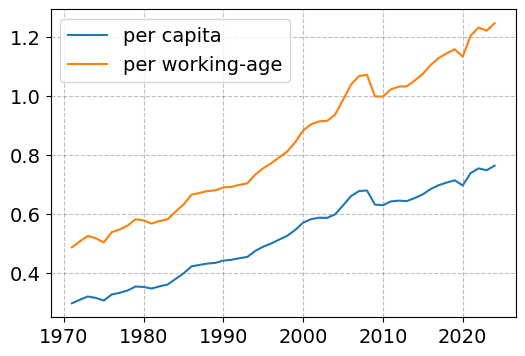

In [155]:
# ages = ?

# working_pop = BEFOLK1[BEFOLK1.ALDER.isin(?)].groupby('year').?
# working_pop = working_pop.drop(columns=['ALDER'])
# working_pop = working_pop.rename(columns={'population':'working_population'})

# merged = pd.merge(nah1, working_pop, how='left', on=['year'])
# merged = pd.merge(merged, pop, how='left', on=['year'])
ages = [f'{age} years' for age in range(18,65+1)]

working_pop = BEFOLK1[BEFOLK1.ALDER.isin(ages)].groupby('year').sum()
working_pop = working_pop.drop(columns=['ALDER'])
working_pop = working_pop.rename(columns={'population':'working_population'})

merged_true = pd.merge(nah1_true, working_pop, how='left', on=['year'])
merged_true = pd.merge(merged_true, pop, how='left', on=['year'])

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(1,1,1)

merged_true['value_pop'] = merged_true.value/merged_true.population
merged_true['value_working_pop'] = merged_true.value/merged_true.working_population

I = merged_true.unit == 'real' 
I &= merged_true.variable == 'Y' 

df = merged_true[I].set_index('year')
ax.plot(df.value_pop, label='per capita')
ax.plot(df.value_working_pop, label='per working-age')

ax.legend()

### 2.3. <a id='toc2_3_'></a>[Split-apply-combine-plot](#toc0_)

Ensure the following code for a **split-apply-combine-plot** can run.

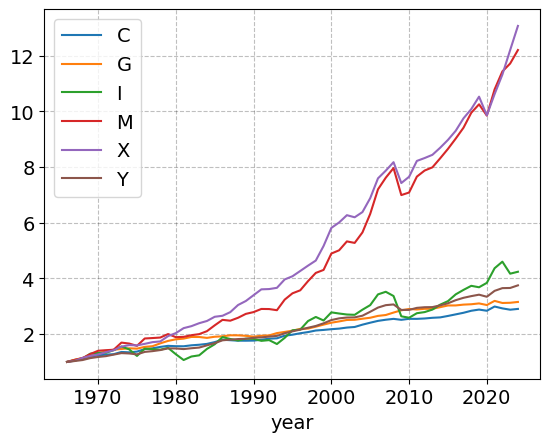

In [149]:
# # a. split
nah1_true_grouped = nah1_true.groupby(['variable','unit'])
nah1_true_grouped_first = nah1_true_grouped.value.first()
nah1_true_grouped_first.name = 'first'

# # b. apply
nah1_true = nah1_true.set_index(['variable','unit','year'])
nah1_true = nah1_true.join(nah1_true_grouped_first,how='left',on=['variable','unit'])
nah1_true = nah1_true.reset_index()

# # c. combine
nah1_true['indexed'] = nah1_true['value']/nah1_true['first']

# # d. plot
def plot(df,variable='indexed'):
     df_indexed = df.set_index('year')
     I = df_indexed.unit == 'real'
     df_indexed[I].groupby(['variable'])[variable].plot(legend=True);
    
plot(nah1_true)

**Question:** Implement the same split-apply-combine as above using `transform`.

In [150]:
def first(x): # select the first element in a series
    return x.iloc[0]
nah1_true_alt = nah1_true.copy()
grouped = nah1_true_alt.groupby(['variable','unit'])
nah1_true_alt['index_transform'] = grouped['value'].transform(lambda x: x/first(x))
nah1_true_alt.head()
# nah1_alt = nah1.copy()
# grouped = nah1_alt.groupby(?)
#nah1_alt[?] = ?.transform(lambda x: ?)
#nah1_alt.head()

,variable,unit,year,value,first,indexed,index_transform
0,M,real,1966,116721.0,116721.0,1.0,1.0
1,X,real,1966,129917.0,129917.0,1.0,1.0
2,I,nominal,1966,21134.0,21134.0,1.0,1.0
3,I,real,1966,137948.0,137948.0,1.0,1.0
4,G,nominal,1966,14768.0,14768.0,1.0,1.0


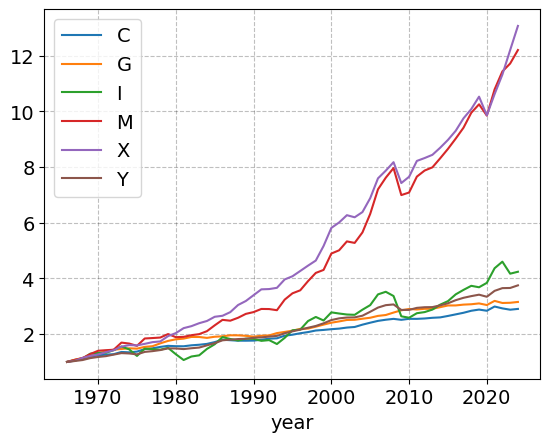

In [153]:
plot(nah1_true_alt,variable='index_transform')